# K Nearest Neighbors

##### K-NN
- Used for both classification and regression.
- Non-parametric, instance-based learning algorithm.
- Non-Parametric:
    - Doesn't make explicit assumptions about the form of the mapping function.
        - h(X):X -> Y
- Instance-Based:
    - Doesn't explicitly learn a model
    - No training stage
    - Training samples are only used during the prediction stage
- k Parameter:
    - Tuning parameter
    - Controls the smoothness of the decision boundary of a k-NN classifier and its fit for a given dataset.
- Effects of k:
    - Small k:
        - High flexibility
        - Sensitive to outliers
        - Exhibits overfitting (low bias and high variance)
        - Decision boundary is more jagged
    - Large k:
        - More resilient to outliers
        - Lower flexibility
        - Exhibits underfitting (high bias and low variance)
        - Decision boundary is more smooth
    - What is the best value of k?
        - Chosen using cross validation
        - Select k that gives the lowest average cross-validation estimate of prediction error.
- What is Cross Validation?
    - Central challenge in ML: Algorithm must perform well on new inputs, not just training data.
    - As model increases in complexity, prediction error also changes. Observed/training data prediction error will decrease as model increases its complexity. On unseen data, prediction error will start to drop down as the model increases its complexity then go back up.
    - We must find a sweet spot for the unseen data where the model is not too complex and also doesn't underfit or be not complex enough.
    - We use error to find the best model complexity.
- Goals of ML:
    - Model selection
    - Model assessment
- How do you choose a model?
    - Find a model that fits future data best.
- How do yoy evaluate a model?
    - Simplest approach: Holdout cross-validation
- Holdout Cross-Validation
    - Randomly split data into training set and testing set
    - Never use test set to train
    - Cons:
        - Fails to use all available data
        - If half of data is for training, poor hypothesis
        - If a tenth of data is for testing, poor estimate of actual accuracy
        - Solution: Repeat training and validation on different randomly chosen subsets of original training set.
- K Fold Cross Validation:
    - Each sample will be used for validation in one of the sets.
    - Each sample serves double duty as training set and validation set.

---

### Scrape Data From Yahoo Finance

In [25]:
#!pip install yfinance

In [26]:
import yfinance

symbol = "DOGE-USD"

start = "2011-01-01"

end = "2021-01-01"

dataframe = yfinance.download(symbol, start, end)

dataframe

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD
Date,,,,,
2017-11-09,0.001415,0.001415,0.001181,0.001207,6259550
2017-11-10,0.001163,0.001431,0.001125,0.001421,4246520
2017-11-11,0.001201,0.001257,0.001141,0.001146,2231080
2017-11-12,0.001038,0.001210,0.001002,0.001189,3288960
2017-11-13,0.001211,0.001212,0.001019,0.001046,2481270
...,...,...,...,...,...
2020-12-27,0.004548,0.004805,0.004429,0.004493,154526399
2020-12-28,0.004592,0.004716,0.004523,0.004548,99641525


In [27]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1149 entries, 2017-11-09 to 2020-12-31
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, DOGE-USD)   1149 non-null   float64
 1   (High, DOGE-USD)    1149 non-null   float64
 2   (Low, DOGE-USD)     1149 non-null   float64
 3   (Open, DOGE-USD)    1149 non-null   float64
 4   (Volume, DOGE-USD)  1149 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.9 KB


In [28]:
dataframe.to_csv("doge_2016_2021.csv")

In [29]:
import pandas as pd
csv_dataframe = pd.read_csv("doge_2016_2021.csv")
csv_dataframe

,Price,Close,High,Low,Open,Volume
0,Ticker,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD
1,Date,NaN,NaN,NaN,NaN,NaN
2,2017-11-09,0.0014149999478831887,0.0014149999478831887,0.0011810000287368894,0.0012069999938830733,6259550
3,2017-11-10,0.0011630000080913305,0.0014309999532997608,0.0011249999515712261,0.001420999993570149,4246520
4,2017-11-11,0.0012009999481961131,0.0012570000253617764,0.0011409999569877982,0.001145999995060265,2231080
...,...,...,...,...,...,...
1146,2020-12-27,0.004548000171780586,0.0048050000332295895,0.004428999964147806,0.0044929999858140945,154526399
1147,2020-12-28,0.004592000041157007,0.0047160000540316105,0.004523000214248896,0.004548000171780586,99641525
1148,2020-12-29,0.004486000165343285,0.004608000162988901,0.0042779999785125256,0.004592000041157007,90876497
1149,2020-12-30,0.004635999910533428,0.00470300018787384,0.004453000146895647,0.004486999940127134,94834499


---

### Process Data

In [30]:
# Create Category Column: Did the price increase or decrease?
import numpy as np

INCREASE = 1

DECREASE = -1

dataframe["Price Increase/Decrease"] = np.where(dataframe["Close"].shift(-1) > dataframe["Close"],
                                               INCREASE,
                                               DECREASE)
dataframe                                                

Price,Close,High,Low,Open,Volume,Price Increase/Decrease
Ticker,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD,DOGE-USD,
Date,,,,,,
2017-11-09,0.001415,0.001415,0.001181,0.001207,6259550,-1
2017-11-10,0.001163,0.001431,0.001125,0.001421,4246520,1
2017-11-11,0.001201,0.001257,0.001141,0.001146,2231080,-1
2017-11-12,0.001038,0.001210,0.001002,0.001189,3288960,1
2017-11-13,0.001211,0.001212,0.001019,0.001046,2481270,-1
...,...,...,...,...,...,...
2020-12-27,0.004548,0.004805,0.004429,0.004493,154526399,1
2020-12-28,0.004592,0.004716,0.004523,0.004548,99641525,-1


In [31]:
X = dataframe.iloc[:, 1:4].values

X

array([[0.001415, 0.001181, 0.001207],
       [0.001431, 0.001125, 0.001421],
       [0.001257, 0.001141, 0.001146],
       ...,
       [0.004608, 0.004278, 0.004592],
       [0.004703, 0.004453, 0.004487],
       [0.004743, 0.004553, 0.004636]])

In [32]:
y = dataframe.iloc[:, -1].values

y

array([-1,  1, -1, ...,  1,  1, -1])

In [33]:
#Split train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

X_train.shape

#Scale data to bring it to same range

(919, 3)

In [34]:
X_test.shape 

(230, 3)

In [35]:
y_train.shape 

(919,)

In [36]:
y_test.shape

(230,)

In [37]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

standard_scaler.fit(X_train)

X_train_scaled = standard_scaler.transform(X_train)

X_train_scaled

array([[ 0.09675098,  0.18804351,  0.11123552],
       [-0.07087236,  0.03528097, -0.03537278],
       [-0.55421342, -0.53692038, -0.55358814],
       ...,
       [ 2.24764568,  2.65990052,  2.38037308],
       [ 1.54568907,  0.33553848,  0.30212557],
       [-0.26833154, -0.22546898, -0.28490603]])

In [38]:
X_test_scaled = standard_scaler.transform(X_test)

X_test_scaled

array([[-2.68874013e-01, -2.03081338e-01, -2.45411530e-01],
       [-3.13356537e-01, -2.51807404e-01, -2.65158782e-01],
       [-5.19495306e-01, -6.53467680e-01, -6.70874831e-01],
       [ 2.14467044e-01,  4.91085705e-02, -2.22078486e-02],
       [ 4.98178899e-01,  4.70522628e-01,  4.17018646e-01],
       [-3.97439443e-01, -4.82268138e-01, -3.54918951e-01],
       [-7.02850275e-01, -6.94950637e-01, -7.05582087e-01],
       [-3.86590081e-01, -4.84901996e-01, -4.45875932e-01],
       [ 8.79535520e-01,  1.19563812e-01,  1.05371737e+00],
       [-4.66875665e-01, -4.65806679e-01, -4.94944927e-01],
       [-2.15711897e-01, -3.47942454e-01, -1.67021071e-01],
       [-3.94184596e-01, -3.57160957e-01, -3.85437506e-01],
       [-1.11241531e+00, -1.28361337e+00, -1.24055281e+00],
       [-6.24192114e-01, -6.12643188e-01, -6.13428295e-01],
       [-4.51144033e-01, -5.06631171e-01, -4.47671149e-01],
       [ 1.20447531e+00,  1.43911654e+00,  1.25777221e+00],
       [-7.19666856e-01, -7.21947374e-01

---

### Build k-NN Classifier

In [39]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors = 30)

model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=30)

In [40]:
models_prediction = model.predict(X_test_scaled)

models_prediction

array([-1, -1,  1,  1, -1,  1, -1,  1, -1, -1,  1, -1, -1, -1,  1, -1,  1,
       -1,  1,  1, -1,  1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1,  1, -1,
        1, -1, -1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1,  1, -1, -1, -1,
       -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1,  1, -1,  1, -1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,
        1, -1,  1,  1, -1, -1, -1,  1, -1, -1, -1,  1,  1, -1, -1, -1,  1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1, -1,
       -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1, -1, -1,  1, -1,  1, -1,
       -1,  1,  1, -1, -1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1, -1, -1,
       -1, -1, -1,  1, -1,  1, -1, -1,  1,  1, -1,  1, -1, -1, -1,  1, -1,
        1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1,  1,
        1, -1,  1, -1,  1,  1, -1,  1, -1, -1,  1, -1,  1, -1, -1, -1, -1,
        1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1, -1,
       -1, -1, -1,  1, -1

In [41]:
#Evaluate algorithm
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, models_prediction)

pd.DataFrame(matrix)                         

,0,1
0,79,42
1,66,43


In [42]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, models_prediction))

              precision    recall  f1-score   support

          -1       0.54      0.65      0.59       121
           1       0.51      0.39      0.44       109

    accuracy                           0.53       230
   macro avg       0.53      0.52      0.52       230
weighted avg       0.53      0.53      0.52       230



In [47]:
#Find Best Value of K by Calculate Error for Different K
K_MIN = 1

K_MAX = 30

errors = []

for i in range(K_MIN, K_MAX):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(X_train, y_train)
    models_prediction = model.predict(X_test)
    errors.append(np.mean(models_prediction !=y_test))

errors   

[0.5,
 0.5217391304347826,
 0.5521739130434783,
 0.5304347826086957,
 0.5,
 0.4782608695652174,
 0.4956521739130435,
 0.48695652173913045,
 0.48695652173913045,
 0.47391304347826085,
 0.508695652173913,
 0.49130434782608695,
 0.5347826086956522,
 0.46956521739130436,
 0.49130434782608695,
 0.508695652173913,
 0.508695652173913,
 0.508695652173913,
 0.5260869565217391,
 0.5,
 0.5130434782608696,
 0.4956521739130435,
 0.5173913043478261,
 0.4782608695652174,
 0.4782608695652174,
 0.45652173913043476,
 0.48695652173913045,
 0.4826086956521739,
 0.47391304347826085]

Text(0, 0.5, 'Error')

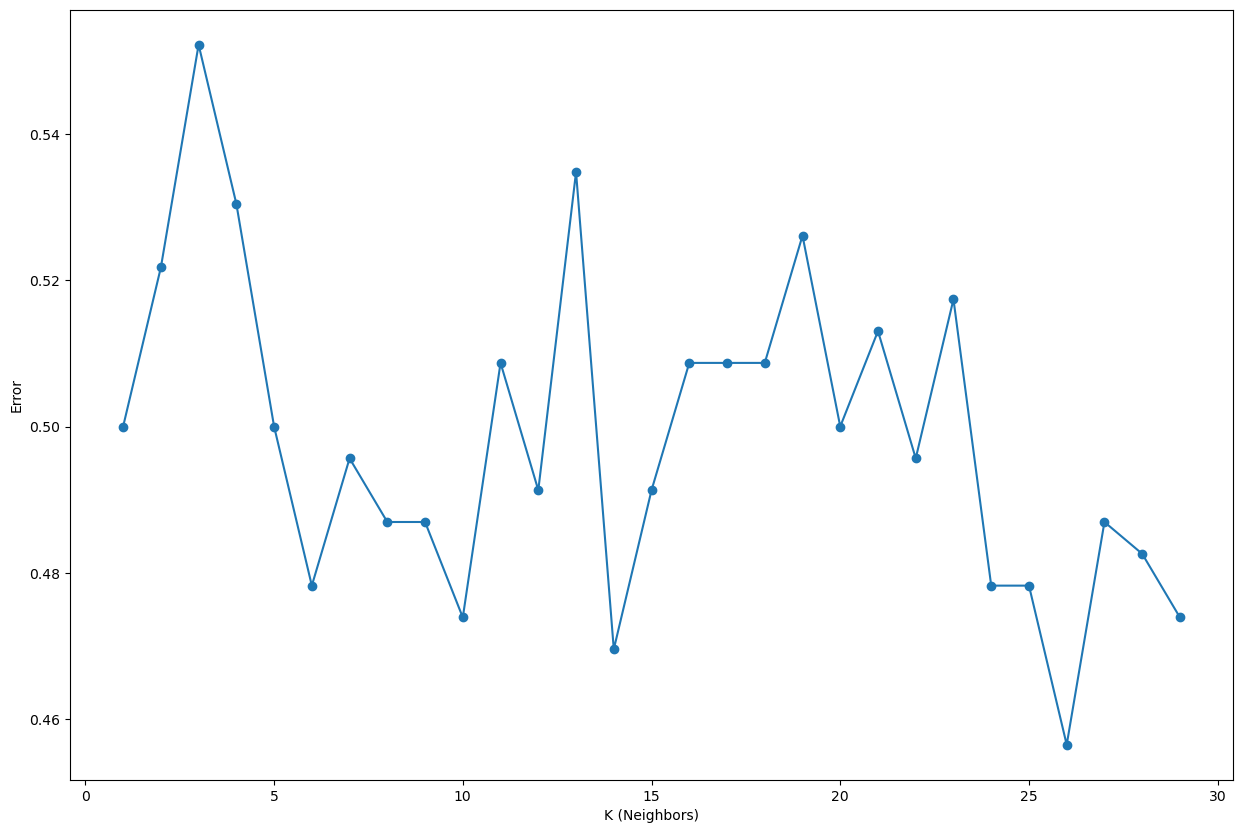

In [52]:
import matplotlib.pyplot as pyplot

pyplot.figure(figsize=(15, 10))

pyplot.plot(range(K_MIN, K_MAX), errors, marker = "o")

pyplot.xlabel("K (Neighbors)")

pyplot.ylabel("Error")